# Homework 6
Silvia Parente 

I tried cross matching from astroquery

In [2]:
import pandas as pd
from astroquery.sdss import SDSS
import time

df = pd.read_csv('shen_subsample_500.csv')

redshifts = []
h_beta_fluxes = []

print(f"start cross match /500")

# 2. Loop through each row in your table
for index, row in df.iterrows():
    plate = int(row['Plate'])
    mjd = int(row['MJD'])
    fiber = int(row['Fiber'])
    query = f"""
    SELECT 
        s.z AS redshift, 
        g.h_beta_flux
    FROM SpecObj s
    JOIN galSpecLine g ON s.specobjid = g.specobjid
    WHERE s.plate = {plate} AND s.mjd = {mjd} AND s.fiberID = {fiber}
    """
    try:
        res = SDSS.query_sql(query)
        if res is not None and len(res) > 0:
            redshifts.append(res['redshift'][0])
            h_beta_fluxes.append(res['h_beta_flux'][0])
            print(f"[{index+1}/{len(df)}]: plate {plate}, MJD {mjd}, fiber {fiber}")
        else:
            redshifts.append(None)
            h_beta_fluxes.append(None)
            print(f"[{index+1}/{len(df)}] no match")
    except Exception as e:
        redshifts.append(None)
        h_beta_fluxes.append(None)
        print(f"[{index+1}/{len(df)}] error")
        
    # avoid overloading SDSS server -_-
    time.sleep(0.5)

df['redshift'] = redshifts
df['h_beta_flux'] = h_beta_fluxes

output_name = 'crossmatched.csv'
df.to_csv(output_name, index=False)
print(f"\n finished")

# check preview 
display(df[['Plate', 'MJD', 'Fiber', 'redshift', 'h_beta_flux']].head())

start cross match /500
[1/500]: plate 1372, MJD 53062, fiber 486
[2/500]: plate 1984, MJD 53433, fiber 609
[3/500]: plate 885, MJD 52379, fiber 449
[4/500]: plate 2614, MJD 54481, fiber 350
[5/500]: plate 1278, MJD 52735, fiber 96
[6/500]: plate 2237, MJD 53828, fiber 448
[7/500]: plate 1372, MJD 53062, fiber 589
[8/500]: plate 2614, MJD 54481, fiber 279
[9/500]: plate 846, MJD 52407, fiber 119
[10/500]: plate 846, MJD 52407, fiber 596
[11/500]: plate 1789, MJD 54259, fiber 190
[12/500]: plate 1790, MJD 53876, fiber 217
[13/500]: plate 1985, MJD 53431, fiber 429
[14/500]: plate 2601, MJD 54144, fiber 271
[15/500]: plate 1975, MJD 53734, fiber 180
[16/500]: plate 1790, MJD 53876, fiber 472
[17/500]: plate 522, MJD 52024, fiber 408
[18/500]: plate 2601, MJD 54144, fiber 378
[19/500]: plate 2239, MJD 53726, fiber 239
[20/500]: plate 495, MJD 51988, fiber 333
[21/500]: plate 1373, MJD 53063, fiber 434
[22/500]: plate 2022, MJD 53827, fiber 553
[23/500]: plate 1317, MJD 52765, fiber 98
[24/

,Plate,MJD,Fiber,redshift,h_beta_flux
0,1372,53062,486,0.228846,323.90260
1,1984,53433,609,0.178252,448.13070
2,885,52379,449,0.201624,86.80108
3,2614,54481,350,0.239360,370.09130
4,1278,52735,96,0.235311,589.24180


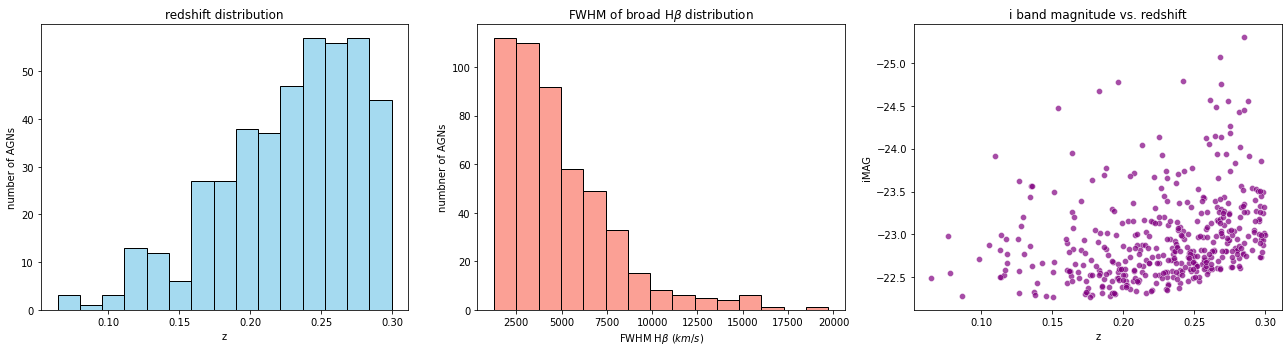

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('crossmatched.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# redshift distrib
sns.histplot(df['redshift'], bins=15, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('redshift distribution')
axes[0].set_xlabel('z')
axes[0].set_ylabel('number of AGNs')

# FWHM distr 
sns.histplot(df['W_BHb_'], bins=15, ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title(r'FWHM of broad H$\beta$ distribution')
axes[1].set_xlabel(r'FWHM H$\beta$ ($km/s$)')
axes[1].set_ylabel('numbner of AGNs')

# i band magnitude vs z
sns.scatterplot(x='redshift', y='iMAG', data=df, ax=axes[2], color='purple', alpha=0.7)
axes[2].invert_yaxis() # lower magnitudes brighter
axes[2].set_title('i band magnitude vs. redshift')
axes[2].set_xlabel('z')
axes[2].set_ylabel('iMAG')

plt.tight_layout()
plt.show()

1. The FWHM distribution of the H$\beta$ line shows that all objects in this sample have broad velocity widths (typically > 1000-2000 km/s). This is a selection bias: the sample only contains Type 1 AGNs (broad line quasars). Type 2 AGNs are excluded.
2. The z distribution is bounded: at higher redshifts, the H$\beta$ emission line gets shifted into the infrared and can no longer be observed by standard SDSS optical instruments.
3. As z increases, the minimum observable brightness also increases; the fainter AGNs at higher z are lost because they fall below the detection threshold of the telescope. 

In [10]:
import numpy as np
import pandas as pd
from scipy.integrate import quad

df = pd.read_csv('crossmatched.csv')

H0 = 67.8           # km / s / Mpc
c = 299792.458      # km / s
Omega_m = 0.31
Omega_L = 0.69

def E(z): return np.sqrt(Omega_m * (1+z)**3 + Omega_L) # Hogg (2000) eq 14

def calc_DL(z):
    integral, error = quad(lambda x: 1/E(x), 0, z)
    Dc = (c / H0) * integral # comoving distance
    Dl_Mpc = (1 + z) * Dc # luminosity distance (Mpc)
    return Dl_Mpc

df['D_L_Mpc'] = df['redshift'].apply(calc_DL)
Mpc_to_cm = 3.08567758e24
df['D_L_cm'] = df['D_L_Mpc'] * Mpc_to_cm

# fluxes are given in 10^-17 erg/s/cm^2
df['L_Hbeta'] = 4 * np.pi * (df['D_L_cm']**2) * (df['h_beta_flux'] * 1e-17)
df['log_L_Hbeta'] = np.log10(df['L_Hbeta'])
df.to_csv('crossmatched2.csv', index=False)
display(df[['Plate', 'redshift', 'h_beta_flux', 'D_L_Mpc', 'log_L_Hbeta']].head())

,Plate,redshift,h_beta_flux,D_L_Mpc,log_L_Hbeta
0,1372,0.228846,323.90260,1175.128117,41.728496
1,1984,0.178252,448.13070,889.116854,41.627233
2,885,0.201624,86.80108,1019.537956,41.033243
3,2614,0.239360,370.09130,1236.253620,41.830435
4,1278,0.235311,589.24180,1212.643651,42.015671


In [11]:
import numpy as np
import pandas as pd

df = pd.read_csv('crossmatched2.csv')

# calc M_BH with eq 2 from Wu (2009)
df['M_BH_Msun'] = 2.4e6 * ((df['L_Hbeta'] / 1e42) ** 0.59) * ((df['W_BHb_'] / 1e3) ** 2)
df['log_M_BH'] = np.log10(df['M_BH_Msun'])
# calc L_bol using eq 8 from Wu (2009)
df['log_L_bol'] = 0.94 * df['log_L_Hbeta'] + 5.39
df['L_bol'] = 10 ** df['log_L_bol']
# calc L_Edd with the formula from Wu (2009) 
df['L_Edd'] = 1.38e38 * df['M_BH_Msun']
df['log_L_Edd'] = np.log10(df['L_Edd'])
# eddington ratio is L_bol / L_Edd
df['Edd_Ratio'] = df['L_bol'] / df['L_Edd'] 
df['log_Edd_Ratio'] = np.log10(df['Edd_Ratio'])

df.to_csv('crossmatched3.csv', index=False)
display(df[['Plate', 'W_BHb_', 'log_L_Hbeta', 'log_M_BH', 'log_L_bol', 'log_Edd_Ratio']].head())

,Plate,W_BHb_,log_L_Hbeta,log_M_BH,log_L_bol,log_Edd_Ratio
0,1372,4399.3,41.728496,7.506791,44.614786,-1.031884
1,1984,2371.4,41.627233,6.910289,44.519599,-0.530568
2,885,10756.6,41.033243,7.873175,43.961248,-2.051805
3,2614,15241.3,41.830435,8.646212,44.710609,-2.075482
4,1278,1385.6,42.015671,6.672733,44.884731,0.072119


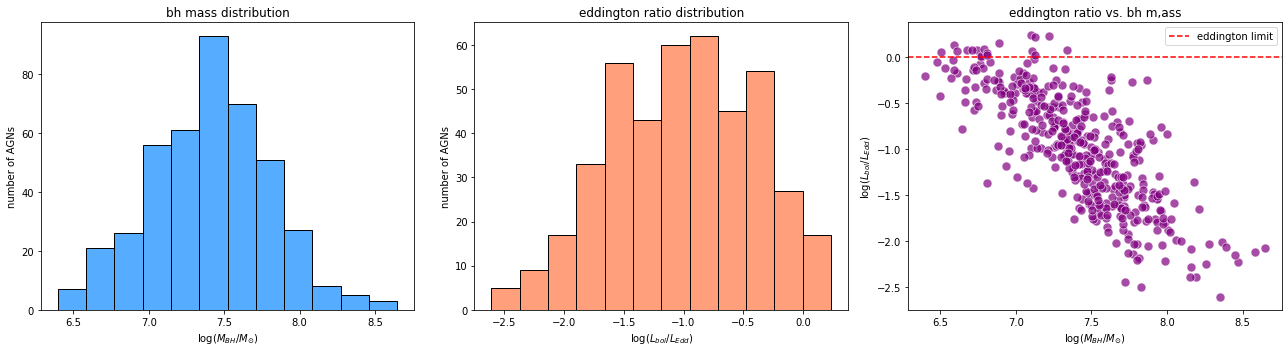

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('crossmatched3.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# hist of bh masses 
sns.histplot(df['log_M_BH'], bins=12, ax=axes[0], color='dodgerblue', edgecolor='black')
axes[0].set_title('bh mass distribution')
axes[0].set_xlabel(r'$\log(M_{BH} / M_{\odot})$')
axes[0].set_ylabel('number of AGNs')
# hist of eddington ratios 
sns.histplot(df['log_Edd_Ratio'], bins=12, ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('eddington ratio distribution')
axes[1].set_xlabel(r'$\log(L_{bol} / L_{Edd})$')
axes[1].set_ylabel('number of AGNs')
# eddington ratio vs. bhm
sns.scatterplot(x='log_M_BH', y='log_Edd_Ratio', data=df, ax=axes[2], color='purple', s=80, alpha=0.7)
axes[2].set_title('eddington ratio vs. bh m,ass')
axes[2].set_xlabel(r'$\log(M_{BH} / M_{\odot})$')
axes[2].set_ylabel(r'$\log(L_{bol} / L_{Edd})$')
# theoretical eddington limit 
axes[2].axhline(0, color='red', linestyle='--', label='eddington limit')
axes[2].legend()
plt.tight_layout()
plt.show()

calculated params for 10 objects:


,Object,z,M_R,New_log_M_BH,Wu_log_M_BH,log_Edd_Ratio
0,3C 268.3,0.372,-21.162571,7.841285,7.8,-0.111164
1,3C 303.1,0.270,-22.347758,8.433879,8.4,-1.033758
2,3C 346,0.162,-23.145987,8.832994,8.8,-1.812873
3,3C 459,0.220,-22.554100,8.537050,8.5,-0.886929
4,PKS 0252-71,0.563,-21.562628,8.041314,8.0,-0.071193
5,PKS 1221-423,0.171,-21.145197,7.832599,7.8,-0.932478
6,PKS 1524-136,1.687,-23.695735,9.107867,9.1,-0.137746
7,PKS 1549-79,0.152,-21.544340,8.032170,8.0,-0.882049
8,B 0830+5813,0.094,-20.749888,7.634944,7.6,-2.934823
9,B 1819+6707,0.221,-22.355166,8.437583,8.4,-2.327462


No handles with labels found to put in legend.


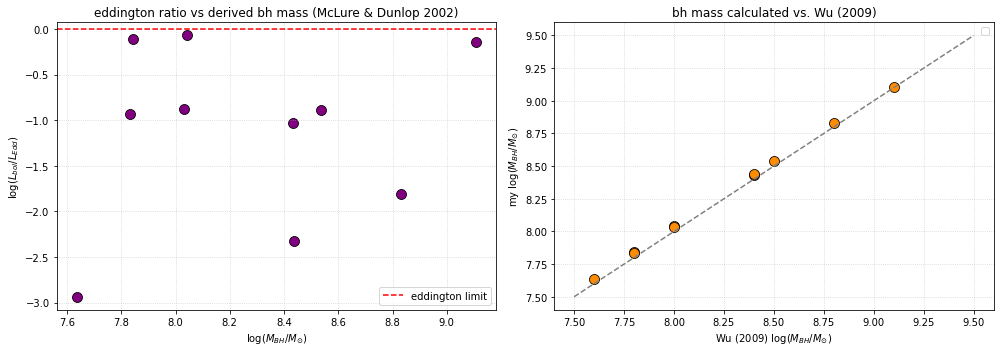

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from astropy.cosmology import FlatLambdaCDM

cosmo_planck = FlatLambdaCDM(H0=67.8, Om0=0.31)

# dataset of 10 objects from Wu (2009) 
# m_R reverse engineered from Wu's absolute magnitudes.
data = [
    {'Object': '3C 268.3', 'z': 0.372, 'm_R': 20.40, 'Wu_log_M_BH': 7.8, 'log_L_bol': 45.87},
    {'Object': '3C 303.1', 'z': 0.270, 'm_R': 18.41, 'Wu_log_M_BH': 8.4, 'log_L_bol': 45.54},
    {'Object': '3C 346',   'z': 0.162, 'm_R': 16.37, 'Wu_log_M_BH': 8.8, 'log_L_bol': 45.16},
    {'Object': '3C 459',   'z': 0.220, 'm_R': 17.70, 'Wu_log_M_BH': 8.5, 'log_L_bol': 45.79},
    {'Object': 'PKS 0252-71', 'z': 0.563, 'm_R': 21.07, 'Wu_log_M_BH': 8.0, 'log_L_bol': 46.11},
    {'Object': 'PKS 1221-423', 'z': 0.171, 'm_R': 18.50, 'Wu_log_M_BH': 7.8, 'log_L_bol': 45.04},
    {'Object': 'PKS 1524-136', 'z': 1.687, 'm_R': 21.86, 'Wu_log_M_BH': 9.1, 'log_L_bol': 47.11},
    {'Object': 'PKS 1549-79', 'z': 0.152, 'm_R': 17.82, 'Wu_log_M_BH': 8.0, 'log_L_bol': 45.29},
    {'Object': 'B 0830+5813', 'z': 0.094, 'm_R': 17.49, 'Wu_log_M_BH': 7.6, 'log_L_bol': 42.84},
    {'Object': 'B 1819+6707', 'z': 0.221, 'm_R': 17.91, 'Wu_log_M_BH': 8.4, 'log_L_bol': 44.25}
]

df = pd.DataFrame(data)

# M_R
df['D_L_Mpc'] = cosmo_planck.luminosity_distance(df['z'].to_numpy()).value
df['D_L_pc'] = df['D_L_Mpc'] * 1e6
df['M_R'] = df['m_R'] - 5 * np.log10(df['D_L_pc']) + 5
# bh mass (McLure & Dunlop 2002)
df['New_log_M_BH'] = -0.5 * df['M_R'] - 2.74
df['New_M_BH'] = 10 ** df['New_log_M_BH']
# eddington ratio
df['L_Edd'] = 1.38e38 * df['New_M_BH']
df['log_L_Edd'] = np.log10(df['L_Edd'])
df['log_Edd_Ratio'] = df['log_L_bol'] - df['log_L_Edd']

print("calculated params for 10 objects:")
display(df[['Object', 'z', 'M_R', 'New_log_M_BH', 'Wu_log_M_BH', 'log_Edd_Ratio']])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# eddington ratio vs derived bhm
sns.scatterplot(x='New_log_M_BH', y='log_Edd_Ratio', data=df, ax=axes[0], color='purple', s=100, edgecolor='black')
axes[0].set_title('eddington ratio vs derived bh mass (McLure & Dunlop 2002)')
axes[0].set_xlabel(r'$\log(M_{BH} / M_{\odot})$')
axes[0].set_ylabel(r'$\log(L_{bol} / L_{Edd})$')
axes[0].axhline(0, color='red', linestyle='--', label='eddington limit')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# comparison with Wu (2009) 
sns.scatterplot(x='Wu_log_M_BH', y='New_log_M_BH', data=df, ax=axes[1], color='darkorange', s=100, edgecolor='black')
axes[1].set_title('bh mass calculated vs. Wu (2009)')
axes[1].set_xlabel(r'Wu (2009) $\log(M_{BH} / M_{\odot})$')
axes[1].set_ylabel(r'my $\log(M_{BH} / M_{\odot})$')
limits = [7.5, 9.5]
axes[1].plot(limits, limits, color='gray', linestyle='--')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()
plt.tight_layout()
plt.show()

manually searched on https://ned.ipac.caltech.edu/ for z and rband for every object.
the bh masses were estimated by using the McLure & Dunlop (2002) relation $\log_{10}(M_{BH}/M_{\odot}) = -0.5M_R - 2.74$. 